# 04. 구매 퍼널·경로 분석과 후속 실험 설계

[문제 정의와 가설](01_problem_hypothesis.md)에서 출발한다. 최초 조회 후 30일을 완전히 관찰할 수 있는 동일 사용자×상품에서 조회(View) → 담기(Cart) → 구매(Purchase) 퍼널을 확인하고, 대표 첫 구매 중 이 경로로 포착되는 규모를 판단한다. 이어 대표 첫 구매를 다섯 경로로 나누고, 별도의 최초 장바구니 담기 후 미구매 집단의 구매 시점을 살펴 후속 실험을 설계한다.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / 'cache_context.json').is_file() and (p / 'sql').is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from query_cache import QueryCache

load_dotenv(PROJECT_ROOT / '.env')
required_env = ('DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_PORT', 'DB_NAME')
if any(not os.getenv(k) for k in required_env):
    raise RuntimeError('캐시 출처 확인용 .env 항목이 부족하다.')
# Engine은 DB 출처 식별에만 사용한다. 캐시 조회는 DB에 연결하지 않는다.
engine = create_engine(URL.create(
    'mysql+pymysql', username=os.environ['DB_USER'], password=os.environ['DB_PASSWORD'],
    host=os.environ['DB_HOST'], port=int(os.environ['DB_PORT']), database=os.environ['DB_NAME'],
))
COMPATIBILITY_FILE = PROJECT_ROOT / 'sql' / 'cache_compatibility.json'

FINAL_CACHE = QueryCache(
    engine=engine, sql_file=PROJECT_ROOT / 'sql' / 'eda.sql',
    upstream_sql_files=(), cache_dir=PROJECT_ROOT / 'cache',
    context_file=PROJECT_ROOT / 'cache_context.json',
)
def read_eda(name, **kwargs):
    return FINAL_CACHE.read_compatible_cached(
        name, compatibility_file=COMPATIBILITY_FILE, **kwargs
    )
import json
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'plotly_mimetype'
COLORS = {'view':'#3B82F6','cart':'#F59E0B','purchase':'#10B981',
          'attention':'#EF4444','neutral':'#94A3B8'}


---
## 1. 한 세션의 조회 → 담기 → 구매는 동일 상품 구매를 얼마나 포착하는가?

<strong>가설 1:</strong> 한 세션에서 조회 → 담기 → 구매가 이어진 경로만으로는 동일 상품 대표 첫 구매의 상당 부분을 포착하지 못할 것이다.

### 1-1. 같은 30일 적격군에서 한 세션 경로와 동일 상품 첫 구매를 비교하면?

최초 동일 상품 조회 이후 30일을 끝까지 관찰할 수 있는 사용자×상품을 한 번씩 센다. 담기는 같은 세션에서 동일 상품 조회보다 늦게 확인된 경우다. 대표 첫 구매가 있다면 그 구매보다 앞선 담기만 포함하고, 구매가 없다면 최초 조회 후 30일 안의 담기를 포함한다. 구매는 대표 첫 구매까지 같은 세션에서 조회 → 담기 → 구매가 순서대로 이어진 경우다.

In [2]:
cohort = read_eda('pj_30day_purchase_cohort').iloc[0]
mart_paths = read_eda('pj_representative_purchase_mart')

# 187건 경계 키·파라미터를 만들고 검증된 제한 조회 캐시만 읽는다.
boundary_keys = mart_paths.loc[
    mart_paths['row_type'].eq('raw 확인 경계'),
    ['user_id', 'product_id', 'anchor_view_at', 'boundary_type'],
].copy()
boundary_keys['user_id'] = boundary_keys['user_id'].astype('int64')
boundary_keys['product_id'] = boundary_keys['product_id'].astype('int64')
boundary_keys['anchor_view_at'] = pd.to_datetime(boundary_keys['anchor_view_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
boundary_json = json.dumps(boundary_keys.to_dict('records'), ensure_ascii=False, separators=(',', ':'))
raw_paths = read_eda('pj_boundary_raw_paths', params={'boundary_json': boundary_json})

eligible_30day = int(cohort['관측가능30일_사용자상품수'])
representative = int(cohort['마트확정_대표첫구매_사용자상품수']) + int((
    raw_paths['boundary_type'].eq('대표 구매 시각 경계')
    & raw_paths['eligible_purchase_flag'].eq(1)
).sum())
confirmed = mart_paths.loc[mart_paths['row_type'].eq('마트 확정 경로')]
raw_classified = raw_paths.loc[raw_paths['eligible_purchase_flag'].eq(1) & raw_paths['path_order'].notna()]
path_counts = confirmed.groupby('path_order').size().add(raw_classified.groupby('path_order').size(), fill_value=0)
same_session = int(path_counts.get(float(1), 0))
outside = representative - same_session
assert len(boundary_keys) == len(raw_paths) == 187
assert raw_paths['eligible_purchase_flag'].eq(1).all() and raw_paths['path_order'].notna().all()
assert (eligible_30day, representative, same_session, outside) == (5_323_764, 342_457, 103_974, 238_483)
# 30일 적격군의 같은 세션 View→Cart 단계만 기존 마트에서 제한 집계했다.
# 마트 시각으로 확정된 683,751개 + 관련 이벤트만 확인한 경계 66개 중 적격 43개.
cart_after_view_30d = 683_751 + 43
assert 43 + 23 == 66
assert (eligible_30day, cart_after_view_30d, same_session) == (5_323_764, 683_794, 103_974)
assert same_session <= cart_after_view_30d <= eligible_30day
funnel_table = pd.DataFrame({
    '동일 상품의 행동 단계': [
        '조회 · 30일 완전 관측',
        '같은 세션에서 조회 후 담기',
        '같은 세션에서 조회 → 담기 → 첫 구매',
    ],
    '사용자×상품 조합 수': [eligible_30day, cart_after_view_30d, same_session],
    '직전 단계 분모': [eligible_30day, eligible_30day, cart_after_view_30d],
    '직전 단계 도달률 (%)': [
        100,
        cart_after_view_30d / eligible_30day * 100,
        same_session / cart_after_view_30d * 100,
    ],
    '조회 후 30일 적격군 대비 (%)': [
        100,
        cart_after_view_30d / eligible_30day * 100,
        same_session / eligible_30day * 100,
    ],
})
display(funnel_table.round(3))

[pj_30day_purchase_cohort] cache HIT 503148ef8f8e · 1행
[pj_representative_purchase_mart] cache HIT e446dce2ac5d · 342,457행
[pj_boundary_raw_paths] cache HIT 84e5f7054019 · 187행


,동일 상품의 행동 단계,사용자×상품 조합 수,직전 단계 분모,직전 단계 도달률 (%),조회 후 30일 적격군 대비 (%)
0,조회 · 30일 완전 관측,5323764,5323764,100.000,100.000
1,같은 세션에서 조회 후 담기,683794,5323764,12.844,12.844
2,같은 세션에서 조회 → 담기 → 첫 구매,103974,683794,15.205,1.953


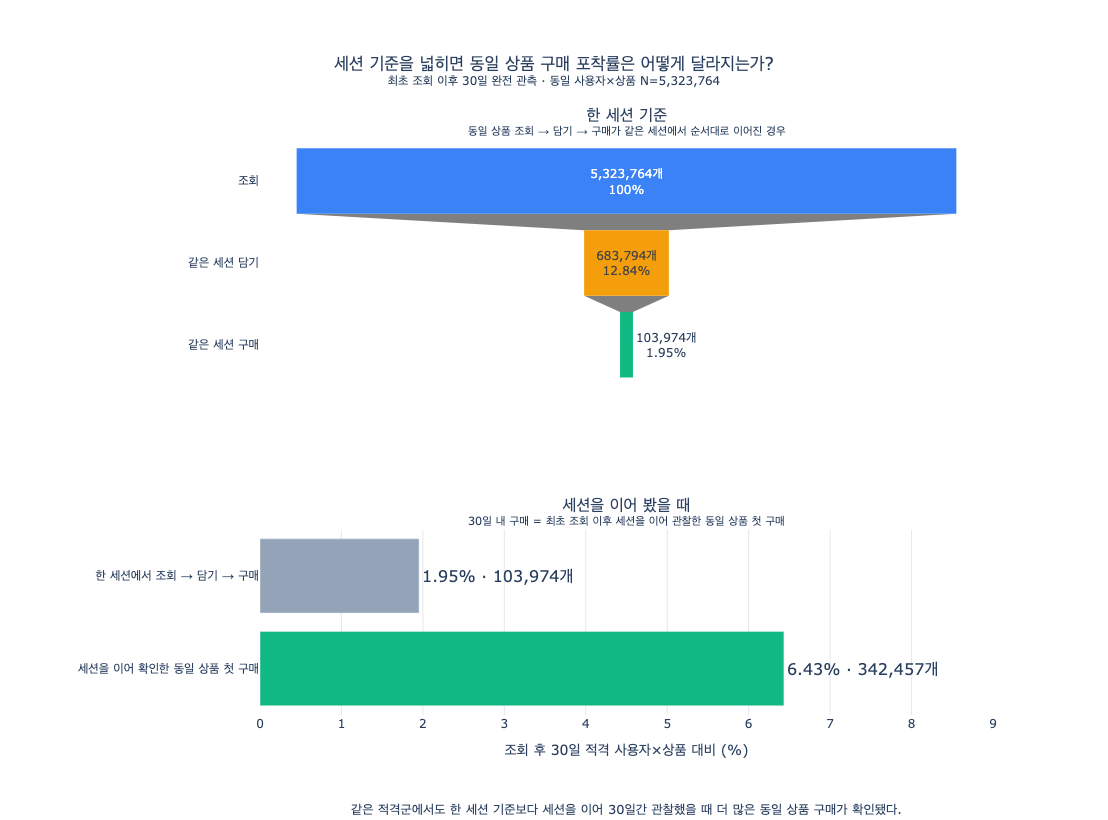

In [3]:
from plotly.subplots import make_subplots

funnel_counts = [eligible_30day, cart_after_view_30d, same_session]
funnel_labels = ['조회', '같은 세션 담기', '같은 세션 구매']
funnel_text = [
    f'{eligible_30day:,}개<br>100%',
    f'{cart_after_view_30d:,}개<br>{cart_after_view_30d / eligible_30day * 100:.2f}%',
    f'{same_session:,}개<br>{same_session / eligible_30day * 100:.2f}%',
]
same_session_pct = same_session / eligible_30day * 100
representative_pct = representative / eligible_30day * 100
fig = make_subplots(
    rows=2, cols=1,
    specs=[[{'type': 'funnel'}], [{'type': 'xy'}]],
    row_heights=[0.57, 0.43], vertical_spacing=0.25,
    subplot_titles=(
        '한 세션 기준<br><sup>동일 상품 조회 → 담기 → 구매가 같은 세션에서 순서대로 이어진 경우</sup>',
        '세션을 이어 봤을 때<br><sup>30일 내 구매 = 최초 조회 이후 세션을 이어 관찰한 동일 상품 첫 구매</sup>',
    ),
)
fig.add_trace(go.Funnel(
    y=funnel_labels, x=funnel_counts,
    text=funnel_text, textinfo='text',
    marker=dict(color=[COLORS['view'], COLORS['cart'], COLORS['purchase']]),
    showlegend=False,
), row=1, col=1)
fig.add_trace(go.Bar(
    x=[same_session_pct, representative_pct],
    y=['한 세션에서 조회 → 담기 → 구매', '세션을 이어 확인한 동일 상품 첫 구매'],
    orientation='h',
    marker_color=[COLORS['neutral'], COLORS['purchase']],
    text=[f'{same_session_pct:.2f}% · {same_session:,}개',
          f'{representative_pct:.2f}% · {representative:,}개'],
    textposition='outside', textfont_size=16, cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
    showlegend=False,
), row=2, col=1)
fig.update_xaxes(title_text='조회 후 30일 적격 사용자×상품 대비 (%)', range=[0, 9],
                 gridcolor='#E5E7EB', row=2, col=1)
fig.update_yaxes(categoryorder='array', categoryarray=[
    '세션을 이어 확인한 동일 상품 첫 구매', '한 세션에서 조회 → 담기 → 구매',
], row=2, col=1)
fig.add_annotation(
    x=0.5, y=-0.18, xref='paper', yref='paper',
    text='같은 적격군에서도 한 세션 기준보다 세션을 이어 30일간 관찰했을 때 더 많은 동일 상품 구매가 확인됐다.',
    showarrow=False, font=dict(size=13),
)
fig.update_layout(
    title=dict(text=f'세션 기준을 넓히면 동일 상품 구매 포착률은 어떻게 달라지는가?<br><sup>최초 조회 이후 30일 완전 관측 · 동일 사용자×상품 N={eligible_30day:,}</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white', height=820, width=1108,
    margin=dict(l=260, r=115, t=140, b=105),
)
fig.show()


30일 적격 사용자×상품 5,323,764개 중 같은 세션에서 동일 상품 조회 후 담기가 확인된 조합은 683,794개(12.844%)다. 그중 대표 첫 구매까지 한 세션에서 조회 → 담기 → 구매로 이어진 조합은 103,974개로, 담기 단계의 15.205%이자 전체 적격군의 1.953%다. 같은 적격군에서 최초 조회 이후 30일 내 동일 상품 첫 구매가 확인된 조합은 342,457개(6.433%)다.

위쪽 퍼널의 단계별 도달률은 직전 단계에 도달한 사용자×상품을 분모로 사용했다. 아래쪽 비교의 두 비율은 동일한 30일 적격 사용자×상품 5,323,764개를 분모로 한다. 342,457개에는 구매 전 담기가 로그에서 확인되지 않은 경우도 포함된다.


### 1-2. 대표 첫 구매 중 한 세션의 조회 → 담기 → 구매가 차지하는 비중은?

같은 30일 적격군에서 대표 첫 구매가 확인된 사용자×상품은 342,457개(적격군의 6.433%)다. 이제 그 구매를 분모로 놓고, 위 퍼널의 최종 단계에 해당하는 한 세션의 조회 → 담기 → 구매와 그 밖의 구매를 구분한다.

In [4]:
purchase_coverage = pd.DataFrame({
    '대표 첫 구매의 한 세션 경로': [
        '한 세션에서 조회 → 담기 → 구매가 이어짐',
        '한 세션의 조회 → 담기 → 구매로 포착되지 않음',
    ],
    '조합 수': [same_session, outside],
    '공통 분모: 대표 첫 구매': [representative, representative],
    '대표 첫 구매 내 비중 (%)': [
        same_session / representative * 100,
        outside / representative * 100,
    ],
})
assert same_session + outside == representative
display(purchase_coverage.round(3))

,대표 첫 구매의 한 세션 경로,조합 수,공통 분모: 대표 첫 구매,대표 첫 구매 내 비중 (%)
0,한 세션에서 조회 → 담기 → 구매가 이어짐,103974,342457,30.361
1,한 세션의 조회 → 담기 → 구매로 포착되지 않음,238483,342457,69.639


대표 첫 구매 342,457개 중 한 세션에서 조회 → 담기 → 구매가 모두 이어진 구매는 103,974개(30.361%)였다. 나머지 238,483개(69.639%)는 이 경로로 포착되지 않았다. 69.639%에는 같은 세션의 담기 → 구매 경로와 구매 전 담기 기록이 확인되지 않은 경로도 포함된다.

같은 30일 적격 사용자×상품을 분모로 한 1.953%와 6.433%는 나란히 볼 수 있다. 다만 두 비율의 차이 전체가 세션 경계 때문은 아니다. 한 세션의 조회 → 담기 → 구매 경로에는 구매 전 담기 기록이 필요하다는 조건도 있기 때문이다.


### 1-3. 가설 1에 대한 판단

대표 첫 구매 342,457개 중 한 세션에서 조회 → 담기 → 구매가 모두 이어진 구매는 103,974개(30.361%)였다. 나머지 238,483개(69.639%)는 이 경로만으로는 포착되지 않아, 한 세션의 순차 퍼널만으로 실제 동일 상품 구매 여정을 설명하는 데 한계가 있었다.

---
## 2. 대표 첫 구매에서 이전 세션의 담기 경로가 가장 큰가?

<strong>가설 2:</strong> 대표 첫 구매의 경로 중 이전 세션에서 동일 상품을 담고 이후 세션에서 구매한 경로가 가장 큰 비중을 차지할 것이다.

가설 1에서 조회 → 담기 → 구매가 한 세션에서 모두 이어지지 않은 대표 첫 구매 238,483개를 확인했다. 이제 <strong>같은 30일 대표 첫 구매 342,457개</strong>를 그대로 분모로 두고 다섯 구매 경로를 비교한다.

### 2-1. 대표 첫 구매의 다섯 경로는 어떻게 분포하는가?

최초 조회 이후 30일 안의 가장 이른 동일 상품 구매만 대표로 삼고, 그보다 뒤의 재구매는 제외한다. ‘구매 전 담기 기록 미확인’ 경로는 구매 세션의 선행 조회가 확인되는지에 따라 나눠, 대표 첫 구매 하나가 다섯 경로 중 하나에만 들어가도록 한다.

In [5]:
# 기존 4경로 중 구매 전 Cart 미확인 키만 제한 조회해 구매 세션 View를 확인한다.
from tableau.export_dashboard_source import build_split_keys, build_purchase_paths

mart_keys, raw_keys, mart_params, raw_params = build_split_keys(mart_paths, raw_paths)
mart_detail = FINAL_CACHE.run('pj_no_cart_mart_view_split', params=mart_params)
raw_detail = FINAL_CACHE.run('pj_no_cart_raw_view_split', params=raw_params)
paths5, paths4, checked_eligible, checked_representative = build_purchase_paths(
    pd.DataFrame([cohort]), mart_paths, raw_paths, mart_detail, raw_detail,
)
assert (len(mart_keys), len(raw_keys)) == (110_454, 61)
assert (checked_eligible, checked_representative) == (eligible_30day, representative)
# 기존 경로 순서는 검증과 파생 변수에만 사용한다. 표·차트는 비중 내림차순으로 표시한다.
paths = paths5.sort_values('경로순서').rename(columns={
    '사용자상품수': '조합 수',
    '분모_대표첫구매': '분모: 대표 첫 구매',
    '대표첫구매내비율_pct': '대표 첫 구매 내 비중 (%)',
})[['경로', '조합 수', '분모: 대표 첫 구매', '대표 첫 구매 내 비중 (%)']]
assert paths['조합 수'].tolist() == [103_974, 14_291, 113_677, 57_679, 52_836]
assert paths['조합 수'].sum() == representative
assert abs(paths['대표 첫 구매 내 비중 (%)'].sum() - 100) < 1e-9
assert paths['조합 수'].iloc[1:].sum() == outside
assert paths['조합 수'].iloc[-2:].sum() == 110_515
same_session_cart_n = int(paths['조합 수'].iloc[:2].sum())
prior_session_cart_n = int(paths['조합 수'].iloc[2])
no_cart_observed_n = int(paths['조합 수'].iloc[3:].sum())
other_paths_n = representative - prior_session_cart_n
assert (same_session_cart_n, prior_session_cart_n, no_cart_observed_n, other_paths_n) == (
    118_265, 113_677, 110_515, 228_780,
)
assert same_session_cart_n + no_cart_observed_n == other_paths_n
# 분류와 수치는 유지하고, 독자에게 보이는 이름과 표시 순서만 정리한다.
path_display_names = {
    '이전 세션 Cart → 대표 첫 구매': '이전 세션에서 담고, 이후 세션에서 구매',
    '같은 세션 View → Cart → Purchase': '한 세션에서 조회 → 담기 → 구매',
    'Cart 미확인 · 구매 세션 View → Purchase': '담기 기록 미확인 · 구매 세션에서 조회 → 구매',
    'Cart 미확인 · 구매 세션 Purchase only': '담기 기록 미확인 · 구매 세션에서 구매만 확인',
    '같은 세션 Cart → Purchase · 앞선 View 미확인': '한 세션에서 담기 → 구매 · 앞선 조회 미확인',
}
assert set(paths['경로']) == set(path_display_names)
paths_display = paths.assign(구매_경로=paths['경로'].map(path_display_names)).sort_values(
    '대표 첫 구매 내 비중 (%)', ascending=False, kind='stable'
)
assert paths_display['조합 수'].tolist() == [113_677, 103_974, 57_679, 52_836, 14_291]
display(paths_display.rename(columns={'구매_경로': '구매 경로'})[
    ['구매 경로', '조합 수', '분모: 대표 첫 구매', '대표 첫 구매 내 비중 (%)']
].round(3))

[pj_no_cart_mart_view_split] cache HIT 34a4988b1d35 · 110,454행
[pj_no_cart_raw_view_split] cache HIT 4d89104eb425 · 61행


,구매 경로,조합 수,분모: 대표 첫 구매,대표 첫 구매 내 비중 (%)
0,"이전 세션에서 담고, 이후 세션에서 구매",113677,342457,33.195
1,한 세션에서 조회 → 담기 → 구매,103974,342457,30.361
2,담기 기록 미확인 · 구매 세션에서 조회 → 구매,57679,342457,16.843
3,담기 기록 미확인 · 구매 세션에서 구매만 확인,52836,342457,15.429
4,한 세션에서 담기 → 구매 · 앞선 조회 미확인,14291,342457,4.173


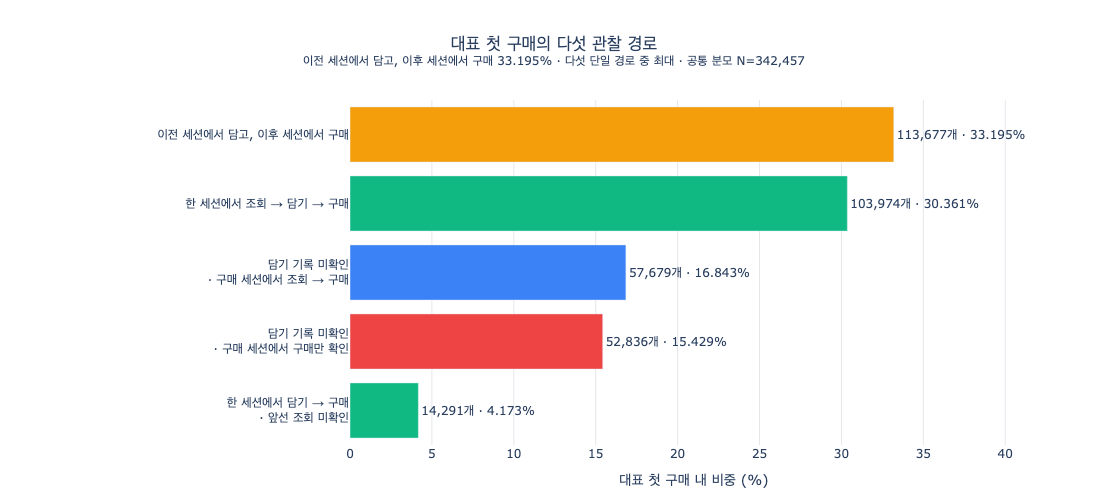

In [6]:
path_colors = dict(zip(paths['경로'], [
    COLORS['purchase'], COLORS['purchase'], COLORS['cart'], COLORS['view'], COLORS['attention']
]))
chart_labels = paths_display['구매_경로'].str.replace(' · ', '<br>· ', regex=False)
fig = go.Figure(go.Bar(
    x=paths_display['대표 첫 구매 내 비중 (%)'], y=chart_labels, orientation='h',
    marker_color=paths_display['경로'].map(path_colors),
    text=[f"{n:,}개 · {p:.3f}%" for n, p in zip(paths_display['조합 수'], paths_display['대표 첫 구매 내 비중 (%)'])],
    textposition='outside', cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'대표 첫 구매의 다섯 관찰 경로<br><sup>이전 세션에서 담고, 이후 세션에서 구매 {prior_session_cart_n / representative * 100:.3f}% · 다섯 단일 경로 중 최대 · 공통 분모 N={representative:,}</sup>', x=0.5),
    xaxis=dict(title='대표 첫 구매 내 비중 (%)', range=[0, 42], gridcolor='#E5E7EB'),
    yaxis=dict(autorange='reversed'), paper_bgcolor='white', plot_bgcolor='white',
    height=500, margin=dict(l=350, r=70, t=100, b=55),
)
fig.show()


다섯 경로의 합은 대표 첫 구매 342,457개다. 비중 내림차순으로 보면, 이전 세션에서 담고 이후 세션에서 구매한 경로가 113,677개(33.195%)로 가장 큰 단일 경로였다. 한 세션에서 조회 → 담기 → 구매한 경로도 103,974개(30.361%)로 비슷한 수준이었다. 다음은 담기 기록 미확인·구매 세션에서 조회 → 구매 57,679개(16.843%), 담기 기록 미확인·구매 세션에서 구매만 확인 52,836개(15.429%), 한 세션에서 담기 → 구매·앞선 조회 미확인 14,291개(4.173%)였다.

담기 기록 미확인은 로그에서 구매 전 담기가 확인되지 않았다는 뜻이다. 구매 세션에서 구매만 확인된 경로도 최초 조회 이후 30일 적격군에 속하므로 이전에 같은 상품을 조회한 적은 있다. 이 경로 구성비는 이미 구매한 조합을 분모로 하며, 미구매 알림 대상의 구매 확률이나 알림 효과를 뜻하지 않는다.


### 2-2. 가설 2에 대한 판단

이전 세션에서 담고, 이후 세션에서 구매한 경로가 113,677개(33.195%)로 다섯 경로 중 가장 큰 단일 경로였다. 관찰된 순위는 가설 2의 예상과 일치한다. 다만 한 세션에서 조회 → 담기 → 구매한 경로도 103,974개(30.361%)로 비슷한 수준이어서 특정 경로가 압도적으로 지배적이라고 보기는 어렵다. 이는 이미 구매한 조합의 경로 구성비이며, 미구매 알림 대상의 구매율이나 알림 효과가 아니다.

---
## 3. 후속 분석 — 최초 장바구니 담기 이후 동일 상품 구매는 언제 집중되는가?

앞에서는 이미 발생한 구매의 경로를 살펴봤다. 이제 실제 알림 대상을 정하기 위해 최초 장바구니 담기 후 같은 상품을 아직 구매하지 않은 집단을 별도로 구성한다. 담기 이후 7일을 끝까지 관찰할 수 있는 사용자×상품에서 시간 구간별 자연 구매율을 확인하며, 각 구간은 시작 시점의 미구매 조합을 분모로 삼는다.

In [7]:
cart_boundary = read_eda('pj_cart_purchase_boundaries').copy()
cart_boundary['user_id'] = cart_boundary['user_id'].astype('int64')
cart_boundary['product_id'] = cart_boundary['product_id'].astype('int64')
cart_boundary['cart_anchor_at'] = pd.to_datetime(cart_boundary['cart_anchor_at']).dt.strftime('%Y-%m-%d %H:%M:%S')
cart_boundary_json = json.dumps(cart_boundary.to_dict('records'), ensure_ascii=False, separators=(',', ':'))
cart_raw = read_eda('pj_cart_boundary_raw_next_purchase', params={'cart_boundary_json': cart_boundary_json})
corrections = [{
    'user_id': int(row.user_id), 'product_id': int(row.product_id),
    'cart_anchor_at': pd.Timestamp(row.cart_anchor_at).strftime('%Y-%m-%d %H:%M:%S'),
    'next_purchase_at': None if pd.isna(row.next_purchase_at) else pd.Timestamp(row.next_purchase_at).strftime('%Y-%m-%d %H:%M:%S'),
} for row in cart_raw.itertuples(index=False)]
correction_json = json.dumps(corrections, ensure_ascii=False, separators=(',', ':'))
cart_params = {'cart_boundary_corrections_json': correction_json}
rates = read_eda('pj_cart_purchase_next_24h_rate', params=cart_params).sort_values('구간순서')
first_two = rates.iloc[:2].copy()
first_two['조건부 구매율 (%)'] = (
    first_two['다음24시간_구매_사용자상품수'] / first_two['구간시작_미구매_사용자상품수'] * 100
)
cart_7day = int(first_two.iloc[0]['구간시작_미구매_사용자상품수'])
first_day_nonpurchase = int(first_two.iloc[1]['구간시작_미구매_사용자상품수'])
first_day_buy = int(first_two.iloc[0]['다음24시간_구매_사용자상품수'])
second_day_buy = int(first_two.iloc[1]['다음24시간_구매_사용자상품수'])
assert len(cart_boundary) == len(cart_raw) == 129
assert (cart_7day, first_day_nonpurchase, first_day_buy, second_day_buy) == (4_082_470, 3_305_169, 777_301, 53_646)
assert cart_7day - first_day_buy == first_day_nonpurchase
timing = pd.DataFrame({
    '최초 장바구니 담기 이후 구간': ['0-24시간', '24-48시간'],
    '동일 상품 구매 조합': [first_day_buy, second_day_buy],
    '구간 시작 미구매 조합': [cart_7day, first_day_nonpurchase],
    '조건부 구매율 (%)': [first_day_buy / cart_7day * 100, second_day_buy / first_day_nonpurchase * 100],
})
display(timing.assign(**{'조건부 구매율 (%)': timing['조건부 구매율 (%)'].map(lambda x: f'{x:.3f}')}))

[pj_cart_purchase_boundaries] cache HIT 5ddc669864da · 129행
[pj_cart_boundary_raw_next_purchase] cache HIT 463ab76ba565 · 129행
[pj_cart_purchase_next_24h_rate] cache HIT 1f09cc930bb4 · 7행


,최초 장바구니 담기 이후 구간,동일 상품 구매 조합,구간 시작 미구매 조합,조건부 구매율 (%)
0,0-24시간,777301,4082470,19.040
1,24-48시간,53646,3305169,1.623


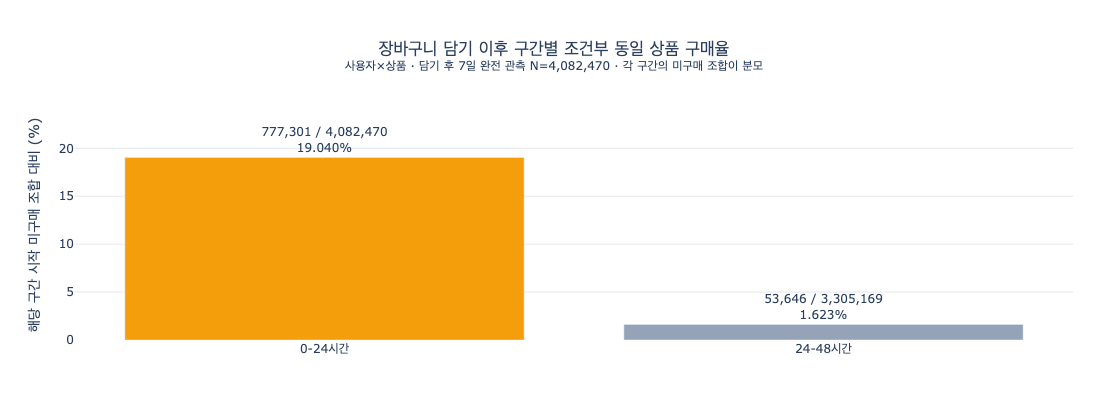

In [8]:
fig = go.Figure(go.Bar(
    x=timing['최초 장바구니 담기 이후 구간'], y=timing['조건부 구매율 (%)'],
    marker_color=[COLORS['cart'], COLORS['neutral']],
    text=[f"{n:,} / {d:,}<br>{p:.3f}%" for n, d, p in zip(timing['동일 상품 구매 조합'], timing['구간 시작 미구매 조합'], timing['조건부 구매율 (%)'])],
    textposition='outside', cliponaxis=False,
    hovertemplate='%{x}<br>%{text}<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'장바구니 담기 이후 구간별 조건부 동일 상품 구매율<br><sup>사용자×상품 · 담기 후 7일 완전 관측 N={cart_7day:,} · 각 구간의 미구매 조합이 분모</sup>', x=0.5),
    yaxis=dict(title='해당 구간 시작 미구매 조합 대비 (%)', range=[0, 24], gridcolor='#E5E7EB'),
    paper_bgcolor='white', plot_bgcolor='white', height=400,
    margin=dict(l=75, r=35, t=110, b=60),
)
fig.show()

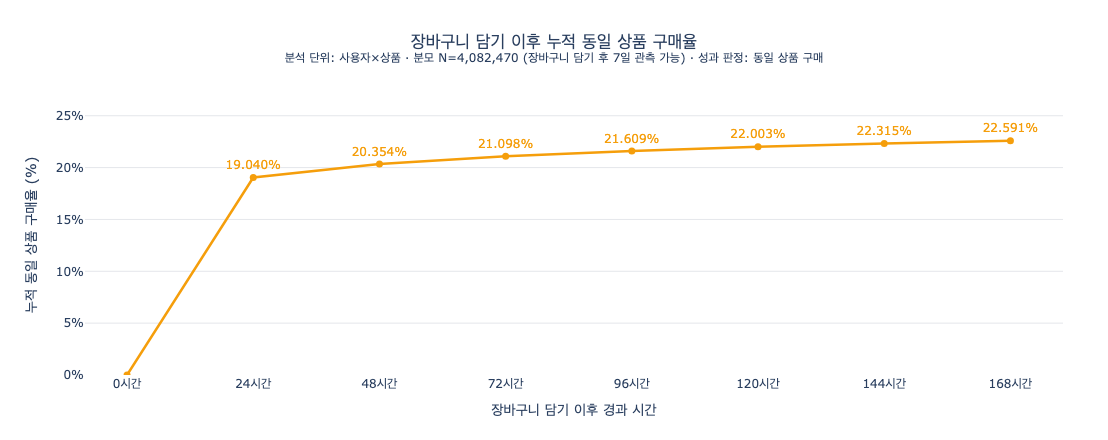

In [9]:
# 구간별 구매 수를 최초 Cart 시점의 동일한 적격군 분모로 누적한다.
assert len(rates) == 7 and cart_7day == 4_082_470
purchase_counts = rates['다음24시간_구매_사용자상품수'].astype('int64')
cumulative_purchases = purchase_counts.cumsum()
cumulative_rates = cumulative_purchases / cart_7day * 100
first24_share = first_day_buy / int(cumulative_purchases.iloc[-1]) * 100
hours = list(range(24, 169, 24))
assert int(purchase_counts.iloc[0]) == first_day_buy
assert round(float(cumulative_rates.iloc[0]), 3) == 19.040
assert round(float(cumulative_rates.iloc[-1]), 3) == 22.591

plot_hours = [0] + hours
plot_rates = [0.0] + cumulative_rates.tolist()
fig = go.Figure(go.Scatter(
    x=plot_hours, y=plot_rates,
    mode='lines+markers+text',
    line=dict(color=COLORS['cart'], width=2.5),
    marker=dict(size=7, color=COLORS['cart']),
    text=[''] + [f'{rate:.3f}%' for rate in cumulative_rates],
    textposition='top center',
    textfont=dict(color=COLORS['cart'], size=12),
    hovertemplate='장바구니 담기 후 %{x}시간<br>누적 동일 상품 구매율 %{y:.3f}%<extra></extra>',
    showlegend=False,
))
fig.update_layout(
    title=dict(text=f'장바구니 담기 이후 누적 동일 상품 구매율<br><sup>분석 단위: 사용자×상품 · 분모 N={cart_7day:,} (장바구니 담기 후 7일 관측 가능) · 성과 판정: 동일 상품 구매</sup>', x=0.5),
    xaxis=dict(title='장바구니 담기 이후 경과 시간', tickmode='array', tickvals=plot_hours,
               ticktext=[f'{h}시간' for h in plot_hours], range=[-8, 178],
               showgrid=False, zeroline=False, showline=False),
    yaxis=dict(title='누적 동일 상품 구매율 (%)', range=[0, 27], dtick=5, ticksuffix='%',
               gridcolor='#E5E7EB', zeroline=False, showline=False),
    paper_bgcolor='white', plot_bgcolor='white', height=440, width=1108,
    margin=dict(l=85, r=45, t=95, b=65),
)
fig.show()


In [10]:
baseline_daily = read_eda('pj_experiment_baseline', params=cart_params)
experiment_eligible = int(baseline_daily['실험적격_사용자상품수'].sum())
experiment_purchase = int(baseline_daily['기준점후_7일_동일상품구매_사용자상품수'].sum())
assert (experiment_eligible, experiment_purchase) == (3_287_385, 154_517)
assert experiment_eligible <= first_day_nonpurchase
baseline = pd.DataFrame({
    '별도 실험 기준선 모집단': ['장바구니 담기 후 24시간까지 동일 상품 미구매 · 이후 7일 완전 관측'],
    '이후 7일 동일 상품 구매 조합': [experiment_purchase],
    '적격 사용자×상품 조합': [experiment_eligible],
    '자연 구매 기준선 (%)': [f'{experiment_purchase / experiment_eligible * 100:.3f}'],
})
display(baseline)

[pj_experiment_baseline] cache HIT da088b64f42d · 144행


,별도 실험 기준선 모집단,이후 7일 동일 상품 구매 조합,적격 사용자×상품 조합,자연 구매 기준선 (%)
0,장바구니 담기 후 24시간까지 동일 상품 미구매 · 이후 7일 완전 관측,154517,3287385,4.700


최초 장바구니 담기 후 0–24시간 구매는 777,301 / 4,082,470개(19.040%)였다. 첫 24시간 미구매 조합의 24–48시간 조건부 구매는 53,646 / 3,305,169개(1.623%)다. 알림 실험의 자연 구매 기준선 4.700%는 장바구니 담기 후 24시간까지 동일 상품을 사지 않았고 이후 7일을 추가로 관측할 수 있는 별도 적격 조합 154,517 / 3,287,385개에서 계산했다. 세 비율은 분모와 관측 종료 시점이 다르다.

첫날 이후 낮아진 자연 구매 신호를 근거로 24시간을 첫 A/B 테스트 후보 시점으로 삼는다. 이 관찰만으로 발송 시점의 우열이나 알림 효과를 판단할 수 없다.

---
## 4. 최종 제안 및 A/B 테스트 설계

후속 분석에서 정한 첫 후보 시점에 맞춰, 최초 장바구니 담기 후 <strong>24시간까지 동일 상품을 구매하지 않은 사용자</strong>에게 장바구니 알림을 보내는 실험을 제안한다. 이 대상은 앞의 대표 첫 구매자에서 뽑지 않는다. 자연 구매 기준선은 미발송 상태의 관찰값이며, 알림 효과는 실험으로 검증해야 한다.

- <strong>배정·처리:</strong> `user_id` 단위 1:1 무작위 배정. 처리군에는 사용자당 한 번 알리고, 적격 상품이 여러 개면 한 알림에 묶는다. 대조군은 발송하지 않는다.
- <strong>주지표:</strong> 기준 시점 후 7일 내 동일 상품을 구매한 적격 `user_id × product_id` 조합 수 / 전체 적격 조합 수. 사용자별 여러 조합은 군집 표준오차로 처리한다.
- <strong>운영 조건:</strong> 실제 발송 전 수신 동의·장바구니 잔존·재고를 확인한다.
- <strong>가드레일:</strong> 수신 거부·신고, 사용자당 전체 구매 건수·전체 매출. 30일 동일 상품 구매율은 보조지표다.

첫 번째 표는 상대 MDE +5%, ICC 약 0.2308, 사용자당 보정 조합 수 약 9.36, 설계효과 약 2.93을 반영한 표본 계산이다. 보정 후 필요한 표본은 약 763,384개 적격 조합, 예상 모집 기간은 약 41–45일이다. 관찰된 유입과 구매율을 이용한 설계 추정치이며 실제 처리 효과는 관찰되지 않았다.

두 번째 표는 같은 기준선과 군집 보정값을 적용한 상대 MDE +10% 시나리오다.


In [11]:
# 검증된 집계 캐시에 정확한 ICC·설계효과를 적용한다. DB 쿼리는 없다.
from experiment_design import calculate_experiment_design

experiment_daily = baseline_daily.copy()
experiment_daily['실험적격일'] = pd.to_datetime(experiment_daily['실험적격일'])
experiment_eligible_n = int(experiment_daily['실험적격_사용자상품수'].sum())
purchase_7day_n = int(experiment_daily['기준점후_7일_동일상품구매_사용자상품수'].sum())
baseline_rate = purchase_7day_n / experiment_eligible_n
assert (experiment_eligible_n, purchase_7day_n) == (3_287_385, 154_517)
daily_pairs = experiment_daily.groupby('실험적격일')['실험적격_사용자상품수'].sum().sort_index()
cluster = read_eda('pj_experiment_user_cluster', params=cart_params)
design = calculate_experiment_design(
    baseline_rate, daily_pairs, relative_mdes=(0.05, 0.10),
    tracking_days=7, cluster_distribution=cluster,
)
design_table = design.sample_size
chosen = design_table.loc[design_table['상대_MDE'].eq('+5%')].iloc[0]
independent_pairs = int(chosen['독립가정_전체표본'])
required_pairs = int(chosen['군집보정_전체표본'])
icc = float(chosen['ICC'])
adjusted_size = float(chosen['설계_보정_클러스터크기'])
design_effect = float(chosen['설계효과'])
target_rate = float(chosen['처리군_목표구매율_pct']) / 100
mean_days = int(chosen['7일추적포함_최소일수'])
low_days = int(chosen['보수적_7일추적포함_일수'])
user_n = int(cluster['사용자수'].sum())
user_days = int(experiment_daily['실험적격_사용자수'].sum())
required_users_upper = -(-required_pairs * user_days // experiment_eligible_n)
required_users_lower = -(-required_pairs * user_n // experiment_eligible_n)
assert (round(icc, 4), independent_pairs, required_pairs, mean_days, low_days) == (
    0.2308, 260_662, 763_384, 41, 45,
)
assert design_table.set_index('상대_MDE').loc['+10%', '군집보정_전체표본'] == 195_258
display(pd.DataFrame({
    '설계 항목': ['자연 구매 기준선', '상대 MDE', '처리군 목표 구매율', '보정 전 필요 표본',
                '사용자 내 ICC', '설계효과', '필요 표본·적격 사용자×상품',
                '배정 기준 사용자 환산 범위', '평균 유입 기준 모집+추적', '낮은 유입 기준 모집+추적'],
    '설계 추정치': [f'{baseline_rate*100:.3f}%', '5%', f'{target_rate*100:.3f}%',
                  f'{independent_pairs:,}쌍', f'{icc:.4f}', f'{design_effect:.2f}배',
                  f'{required_pairs:,}쌍', f'{required_users_lower:,}~{required_users_upper:,}명',
                  f'약 {mean_days}일', f'약 {low_days}일'],
}))

[pj_experiment_user_cluster] cache HIT 49e04b3161d2 · 4,485행


,설계 항목,설계 추정치
0,자연 구매 기준선,4.700%
1,상대 MDE,5%
2,처리군 목표 구매율,4.935%
3,보정 전 필요 표본,"260,662쌍"
4,사용자 내 ICC,0.2308
5,설계효과,2.93배
6,필요 표본·적격 사용자×상품,"763,384쌍"
7,배정 기준 사용자 환산 범위,"81,600~139,320명"
8,평균 유입 기준 모집+추적,약 41일
9,낮은 유입 기준 모집+추적,약 45일


In [12]:
# 동일한 계산 결과에서 상대 MDE +10% 행만 읽어 추가로 표시한다.
chosen_10 = design_table.loc[design_table['상대_MDE'].eq('+10%')].iloc[0]
independent_pairs_10 = int(chosen_10['독립가정_전체표본'])
required_pairs_10 = int(chosen_10['군집보정_전체표본'])
target_rate_10 = float(chosen_10['처리군_목표구매율_pct']) / 100
icc_10 = float(chosen_10['ICC'])
design_effect_10 = float(chosen_10['설계효과'])
mean_days_10 = int(chosen_10['7일추적포함_최소일수'])
low_days_10 = int(chosen_10['보수적_7일추적포함_일수'])
required_users_upper_10 = -(-required_pairs_10 * user_days // experiment_eligible_n)
required_users_lower_10 = -(-required_pairs_10 * user_n // experiment_eligible_n)
assert (independent_pairs_10, required_pairs_10) == (66_672, 195_258)
assert abs(icc_10 - icc) < 1e-12 and abs(design_effect_10 - design_effect) < 1e-12
display(pd.DataFrame({
    '설계 항목': ['자연 구매 기준선', '상대 MDE', '처리군 목표 구매율', '보정 전 필요 표본',
                '사용자 내 ICC', '설계효과', '필요 표본·적격 사용자×상품',
                '배정 기준 사용자 환산 범위', '평균 유입 기준 모집+추적', '낮은 유입 기준 모집+추적'],
    '설계 추정치': [f'{baseline_rate*100:.3f}%', '10%', f'{target_rate_10*100:.3f}%',
                  f'{independent_pairs_10:,}쌍', f'{icc_10:.4f}', f'{design_effect_10:.2f}배',
                  f'{required_pairs_10:,}쌍', f'{required_users_lower_10:,}~{required_users_upper_10:,}명',
                  f'약 {mean_days_10}일', f'약 {low_days_10}일'],
}))


,설계 항목,설계 추정치
0,자연 구매 기준선,4.700%
1,상대 MDE,10%
2,처리군 목표 구매율,5.170%
3,보정 전 필요 표본,"66,672쌍"
4,사용자 내 ICC,0.2308
5,설계효과,2.93배
6,필요 표본·적격 사용자×상품,"195,258쌍"
7,배정 기준 사용자 환산 범위,"20,872~35,636명"
8,평균 유입 기준 모집+추적,약 16일
9,낮은 유입 기준 모집+추적,약 17일


---
## 5. 분석 한계

로그에 조회·담기가 보이지 않아도 실제 행동이 없었다고 단정할 수 없다. 세션 경로, 30일 대표 첫 구매, 최초 장바구니 담기 집단은 각각 관찰 단위와 분모가 다르며, 관찰된 시간 차이는 인과 효과를 뜻하지 않는다. 표본과 기간 추정은 자연 구매율·일 유입·사용자별 상품 묶임이 실험 중에도 유지된다는 가정에 의존한다. 발송·노출 로그가 없어 이 결과는 A/B 테스트 설계안이며, 캠페인 효과를 측정한 결과가 아니다.